In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv(r'C:\Users\prith\Downloads\Higgs\higgs-signal-classifier\data\processed\higgs_with_labels.csv')

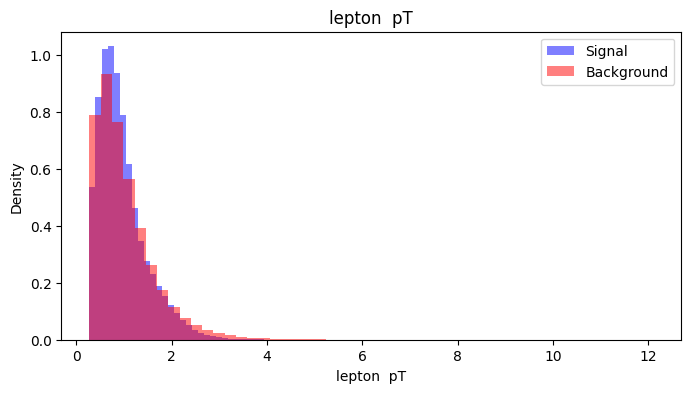

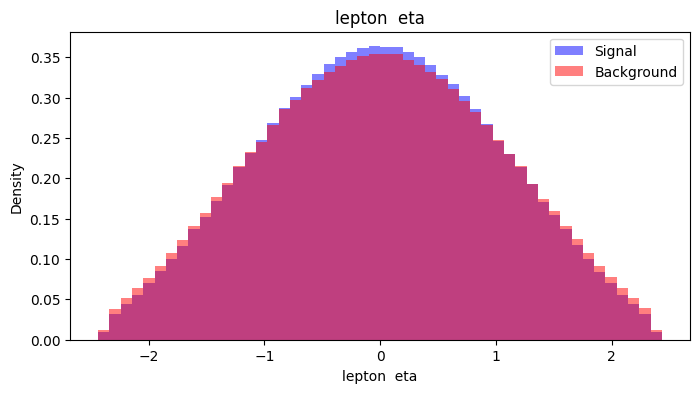

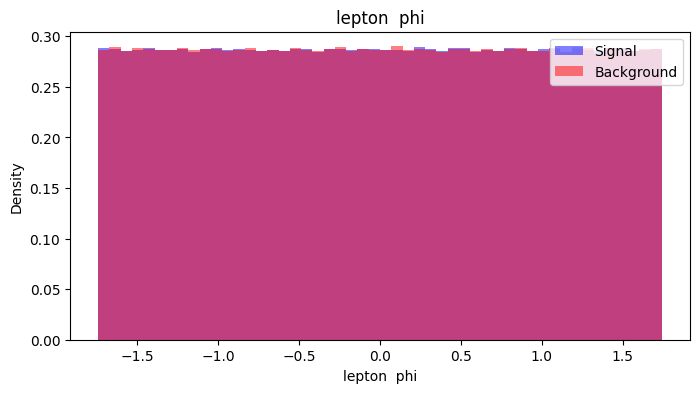

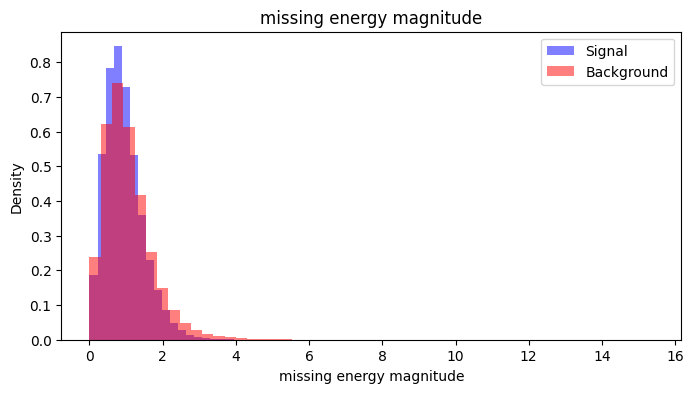

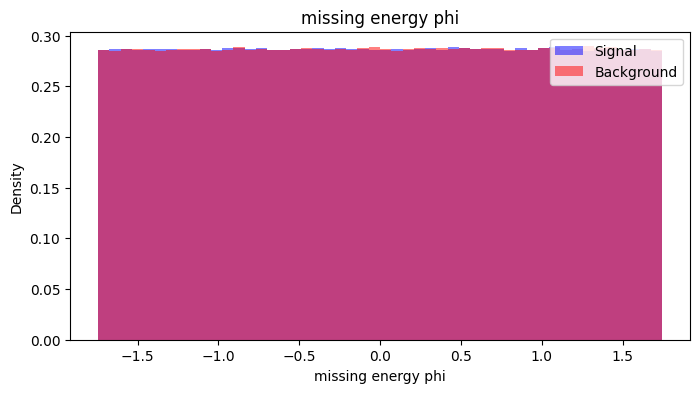

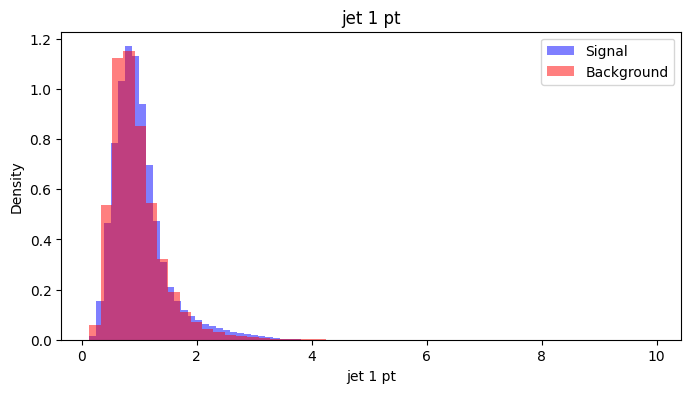

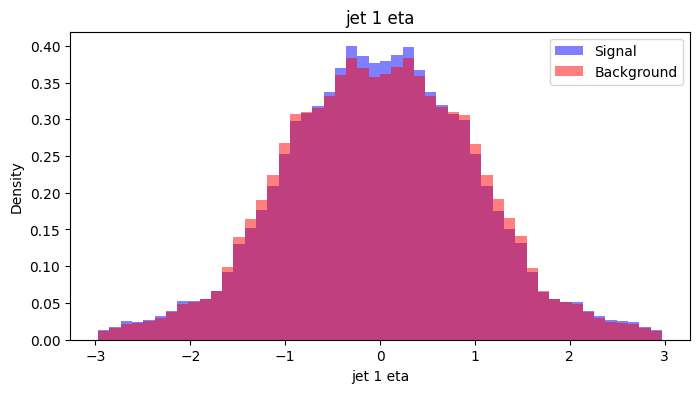

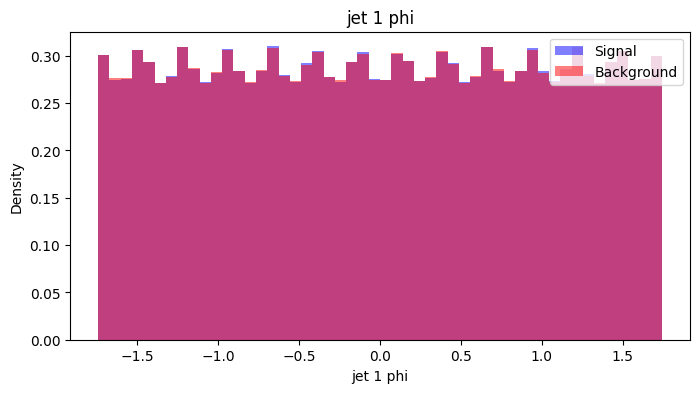

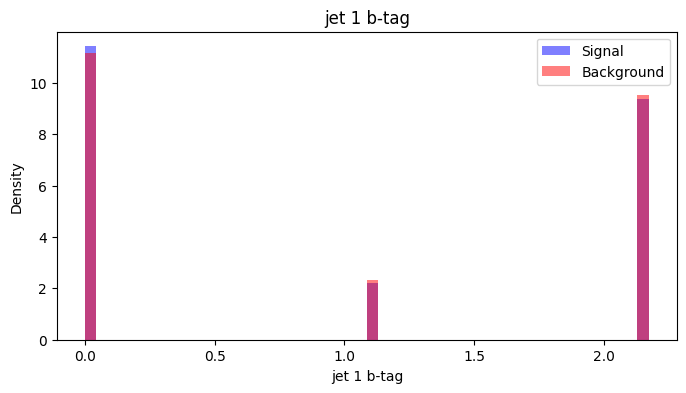

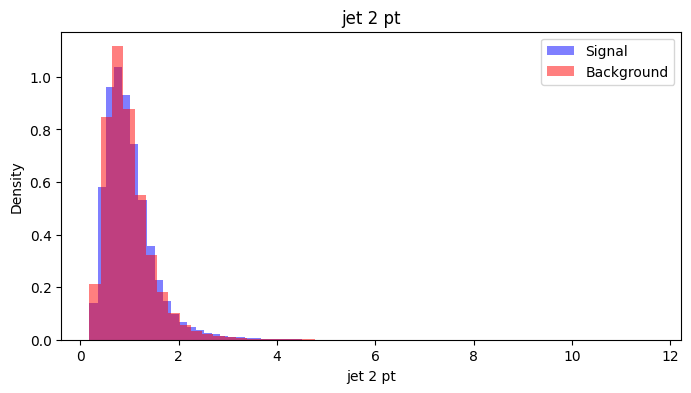

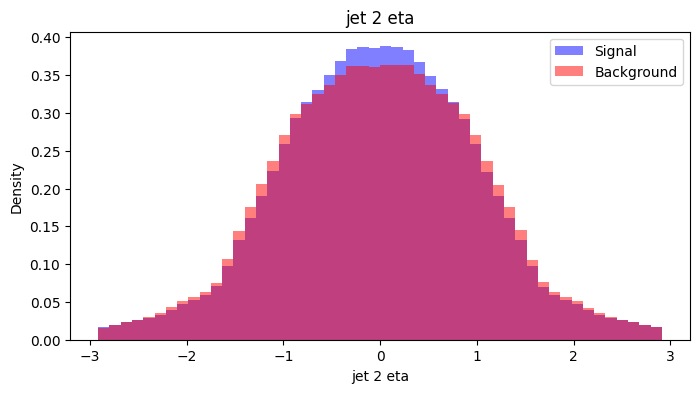

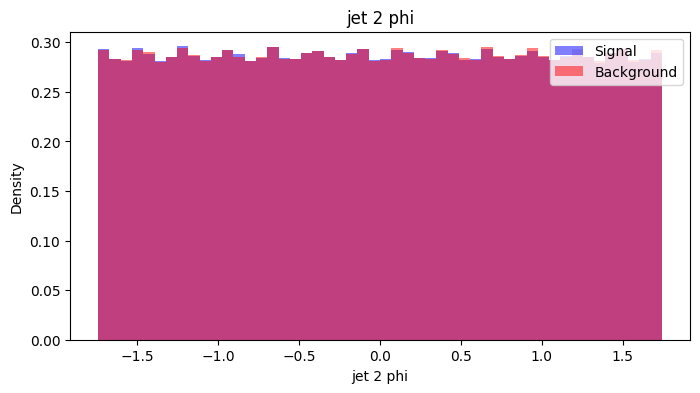

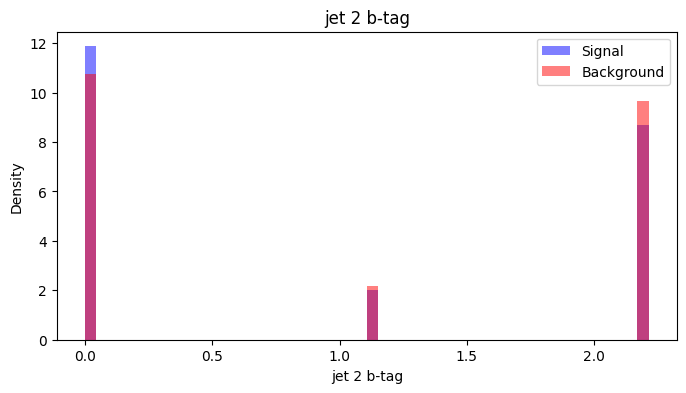

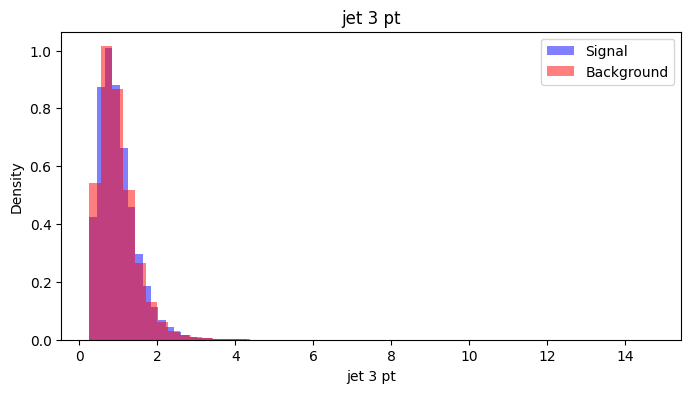

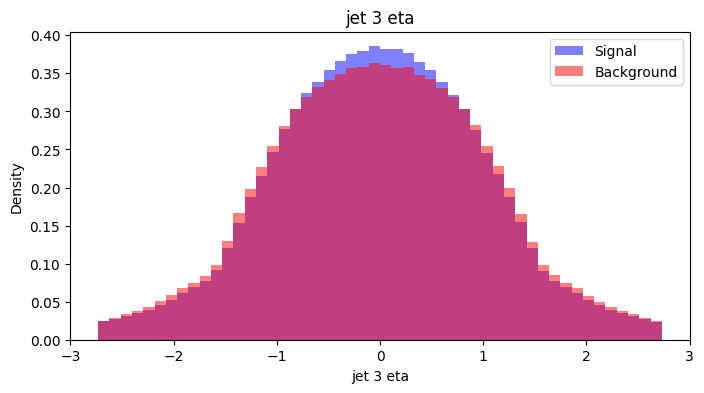

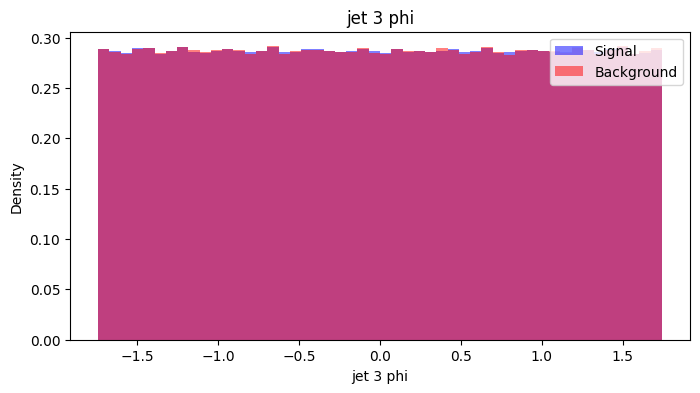

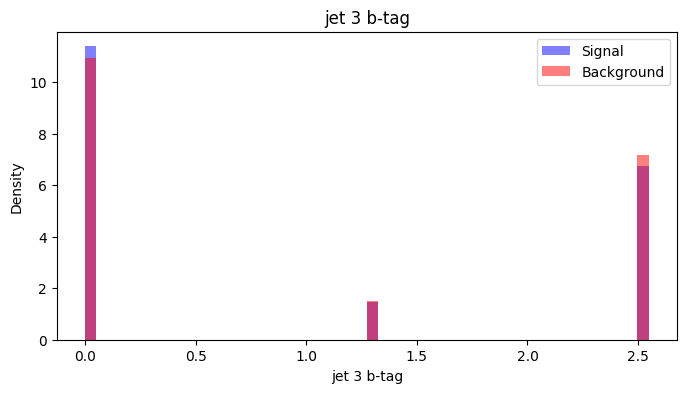

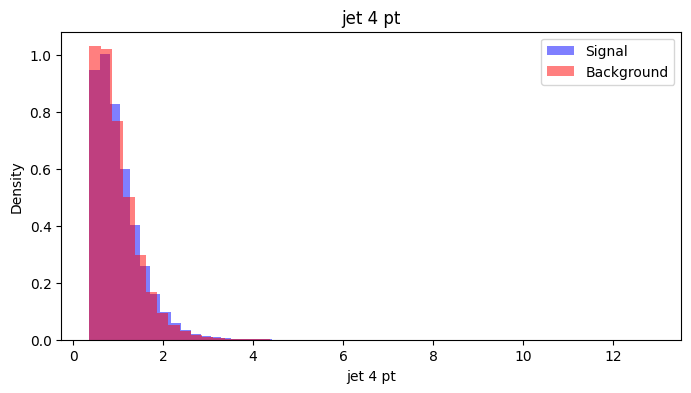

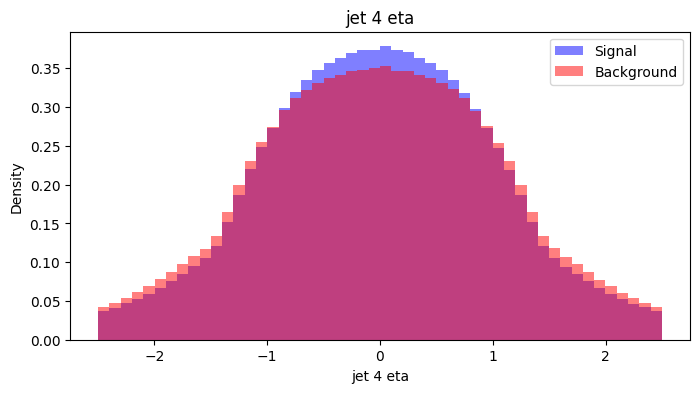

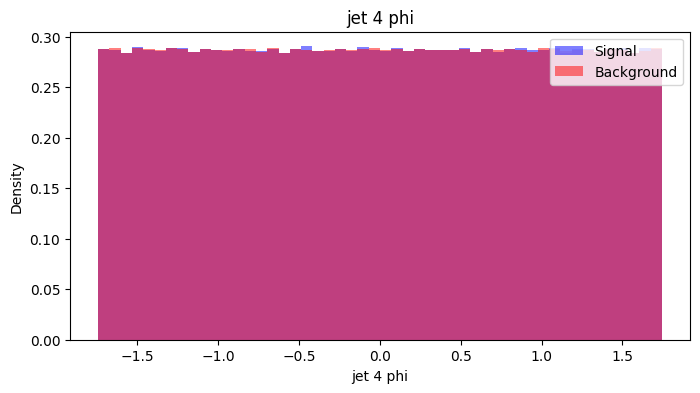

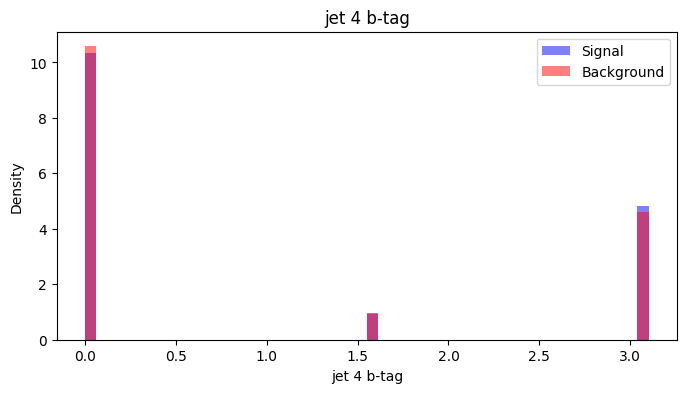

In [16]:
signal = df[df['labels'] == 1]
background = df[df['labels'] ==0]

low_level_features = ['lepton  pT', 'lepton  eta', 'lepton  phi', 'missing energy magnitude', 'missing energy phi', 'jet 1 pt', 'jet 1 eta', 'jet 1 phi', 'jet 1 b-tag', 'jet 2 pt', 'jet 2 eta', 'jet 2 phi', 'jet 2 b-tag', 'jet 3 pt', 'jet 3 eta', 'jet 3 phi', 'jet 3 b-tag', 'jet 4 pt', 'jet 4 eta', 'jet 4 phi', 'jet 4 b-tag']

for feature in low_level_features:
    plt.figure(figsize=(8, 4))
    plt.hist(signal[feature], color='blue', label='Signal', 
                alpha=0.5, bins=50, density=True)
    plt.hist(background[feature], color='red', label='Background', 
                alpha=0.5, bins=50, density=True)
    plt.legend()
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.title(feature)
    plt.show()

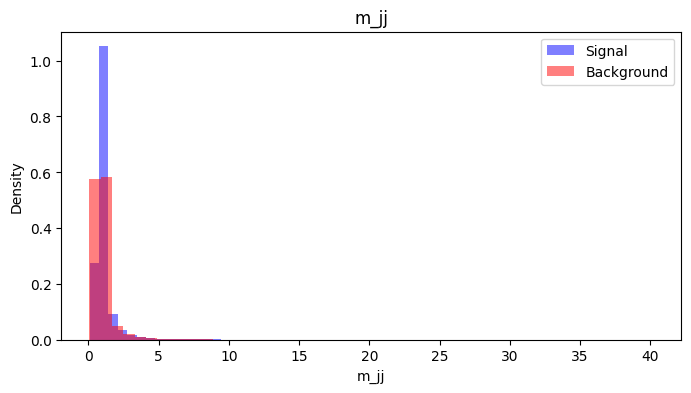

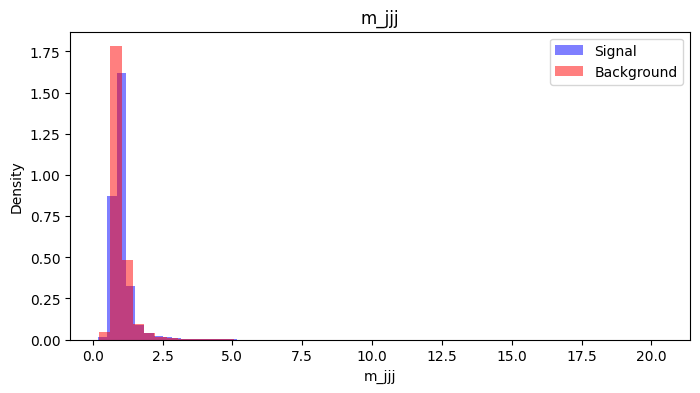

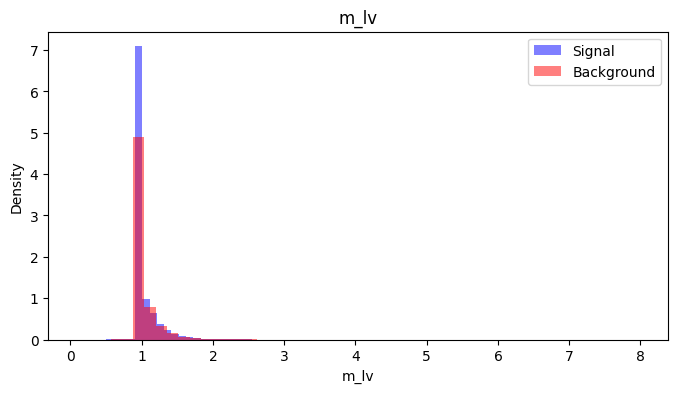

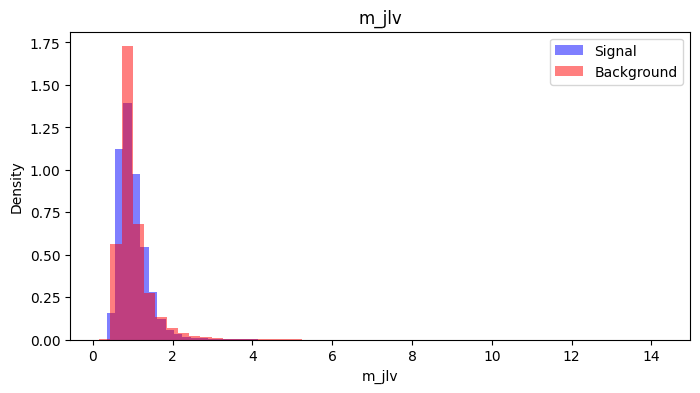

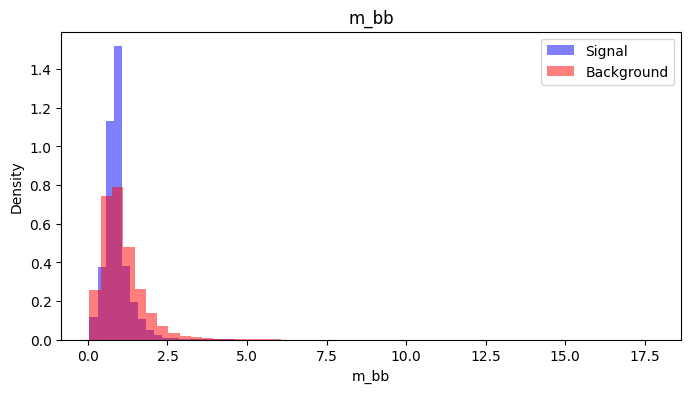

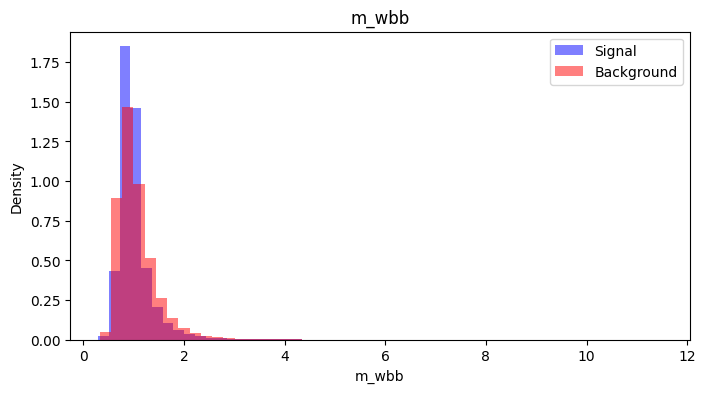

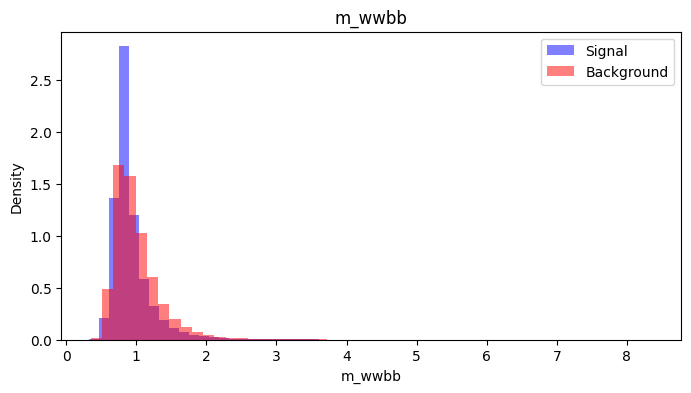

In [17]:
signal = df[df['labels'] == 1]
background = df[df['labels'] ==0]

high_level_features = ['m_jj', 'm_jjj', 'm_lv', 'm_jlv', 'm_bb', 'm_wbb', 'm_wwbb']

for feature in high_level_features:
    plt.figure(figsize=(8, 4))
    plt.hist(signal[feature], color='blue', label='Signal', 
                alpha=0.5, bins=50, density=True)
    plt.hist(background[feature], color='red', label='Background', 
                alpha=0.5, bins=50, density=True)
    plt.legend()
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.title(feature)
    plt.show()

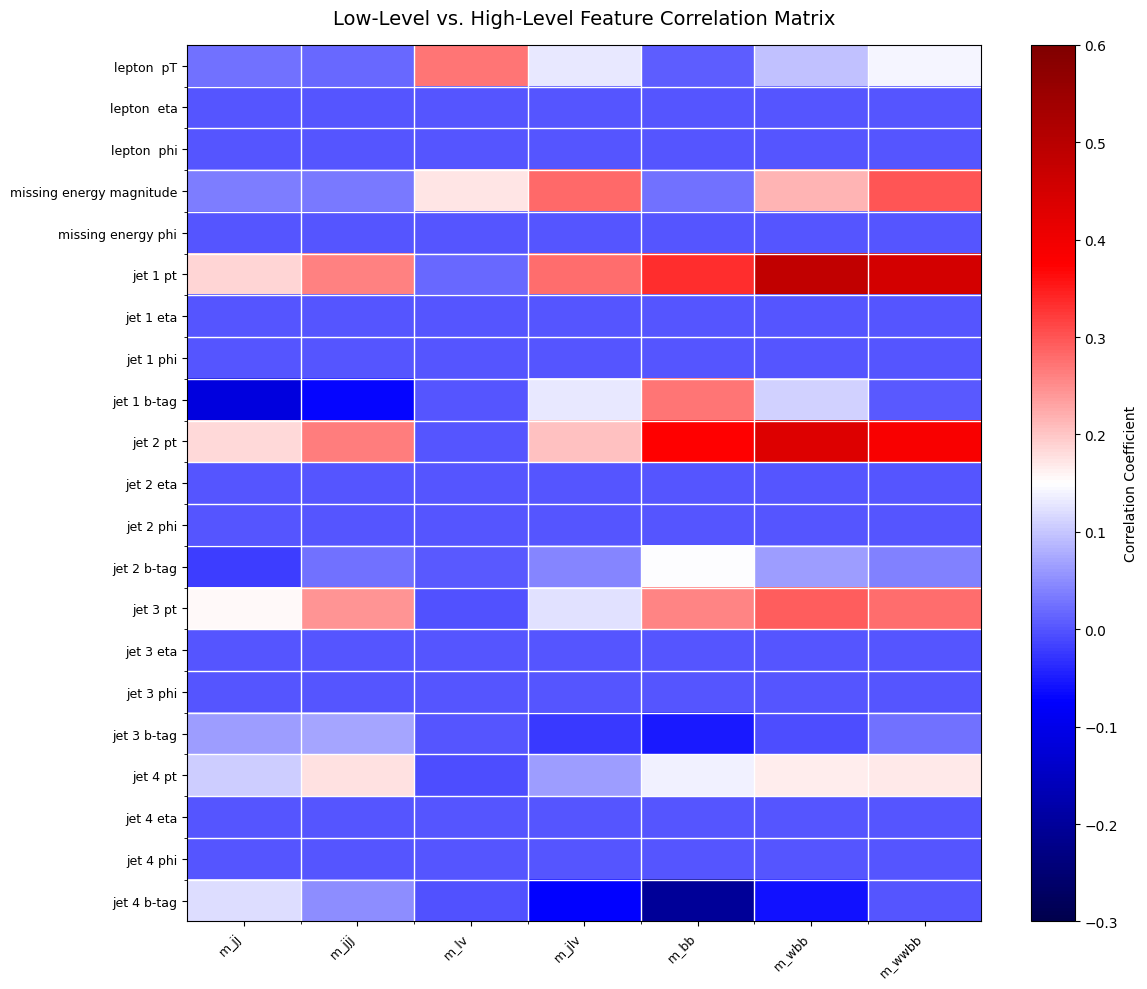

In [59]:
cols_to_drop = [c for c in ['labels', 'Unnamed: 0'] if c in df.columns]
clean_df = df.drop(columns=cols_to_drop)

all_features = list(clean_df.columns)
low_level_features = all_features[:21]
high_level_features = all_features[21:]

cross_corr = clean_df[low_level_features].corrwith(clean_df[high_level_features])
cross_corr_matrix = clean_df.corr().loc[low_level_features, high_level_features]

plt.figure(figsize=(12, 10))
plt.imshow(cross_corr_matrix, cmap='seismic', aspect='auto', vmin=-0.3, vmax=0.6)
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(high_level_features)), high_level_features, rotation=45, ha='right', fontsize=9)
plt.yticks(range(len(low_level_features)), low_level_features, fontsize=9)

plt.gca().set_xticks([x - 0.5 for x in range(1, len(high_level_features))], minor=True)
plt.gca().set_yticks([y - 0.5 for y in range(1, len(low_level_features))], minor=True)
plt.grid(which='minor', color='white', linestyle='-', linewidth=1)

plt.title('Low-Level vs. High-Level Feature Correlation Matrix', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

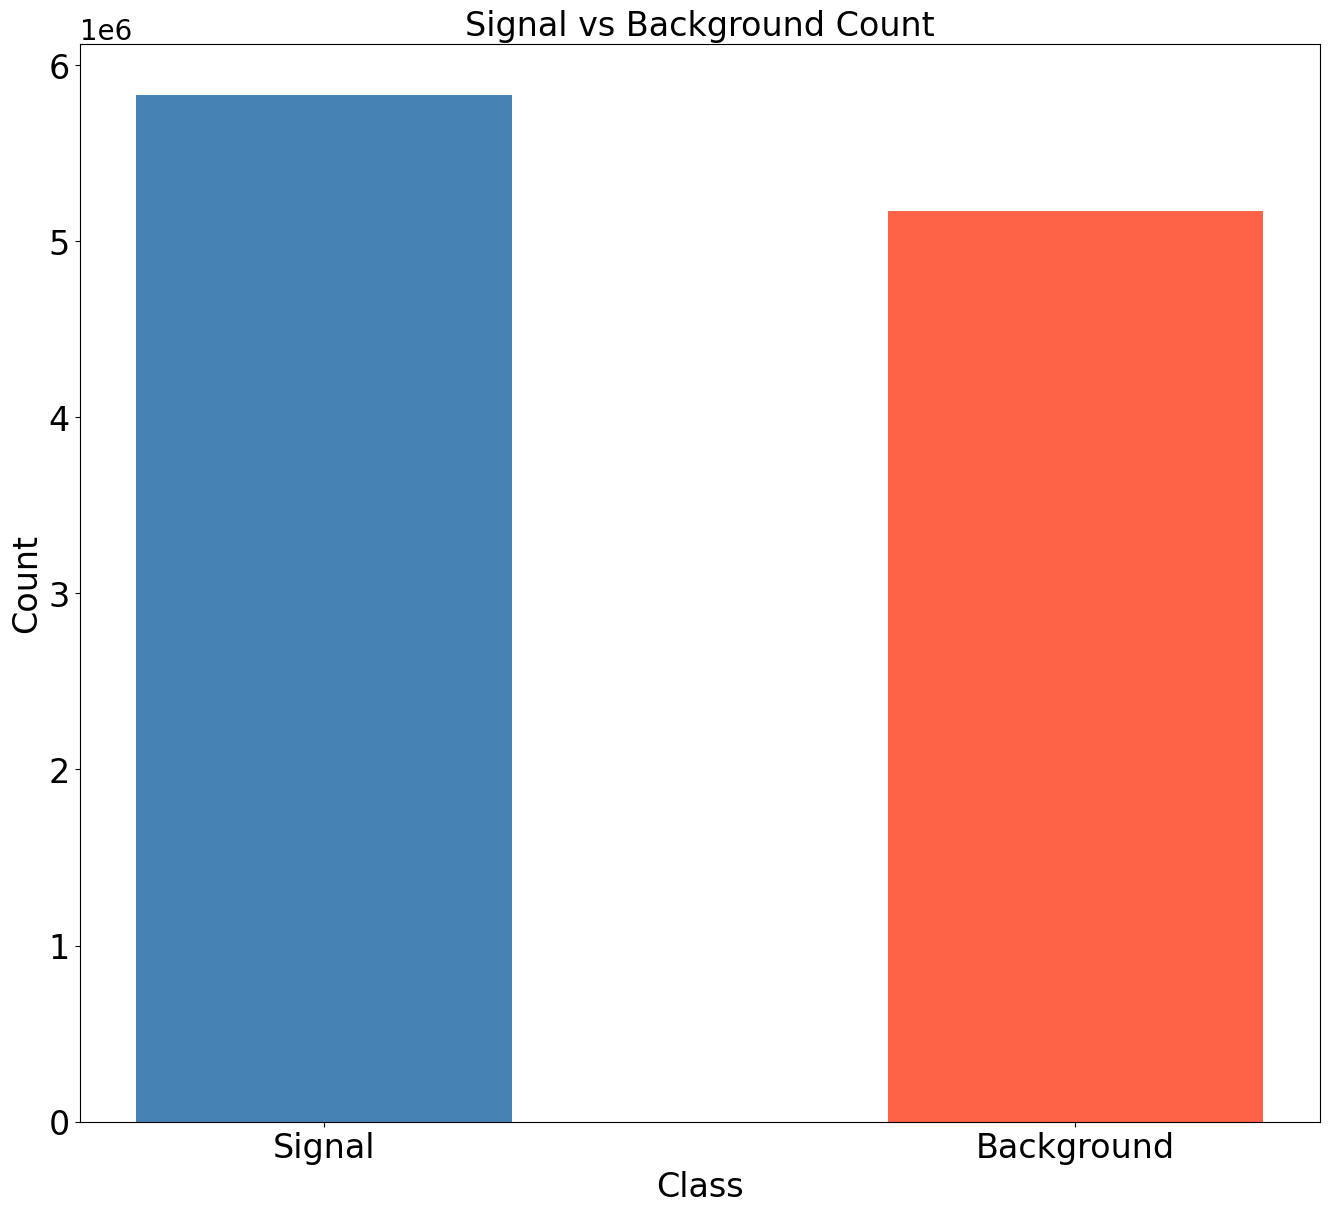

In [52]:
fig, ax = plt.subplots(figsize=(16, 14))

count_sig = len(df[df['labels']==1])
count_bac = len(df[df['labels']==0])

ax.bar(['Signal', 'Background'], [count_sig, count_bac], width=0.5, color=['steelblue', 'tomato'])
ax.set_xlabel('Class', fontsize= 24)
ax.set_ylabel('Count', fontsize= 24)
ax.set_title('Signal vs Background Count', fontsize= 24)
ax.yaxis.get_offset_text().set_fontsize(20)
ax.tick_params(axis='both', labelsize=24)
plt.show()